# Validation for the Vision Transformers on CIFAR-10 and Tiny ImageNET-200

On the following notebook we are going to validate the hypeparameters of our vision transformer model in order to find the best version of the Vision Transformer model for each of the specific datasets. On this notebook we are going to validate over the following hyperparameters:

* Number of Heads:
* MLP Ratio:
* DroupOut Rate:

In [4]:
import os

REPO_NAME = "4803_project_advanced_neural_networks"
REPO_URL = "https://github.com/zarcop/4803_project_advanced_neural_networks"
if not os.path.isdir(REPO_NAME):
    !git clone {REPO_URL}
else:
    !git -C {REPO_NAME} pull

Already up to date.


## CIFAR-10: Vision Transformer hyperparameter validation (Stratified K-Fold)

Sweeps **num_heads**, **dropout** (attention + MLP + positional dropout in `Vision_Transformers`), and **mlp_ratio**, with CIFAR-10 preprocessing aligned with the other notebooks (tensor + channel normalize).


Imported vision_transformers from: /content/4803_project_advanced_neural_networks/model/vision_transformers.py
Vision_Transformers signature: (self, img_size, patch_size, in_channels, k_classes, embedded_dim, depth, num_heads, mlp_ratio, dropout)
Device: cuda

Config: heads=2, drop=0.0, mlp_ratio=2.0
  Fold 1/3: val_acc=52.82%
  Fold 2/3: val_acc=54.76%
  Fold 3/3: val_acc=54.82%

Config: heads=2, drop=0.0, mlp_ratio=3.0
  Fold 1/3: val_acc=53.21%
  Fold 2/3: val_acc=55.09%
  Fold 3/3: val_acc=55.33%

Config: heads=2, drop=0.0, mlp_ratio=4.0
  Fold 1/3: val_acc=55.94%
  Fold 2/3: val_acc=54.88%
  Fold 3/3: val_acc=55.21%

Config: heads=2, drop=0.1, mlp_ratio=2.0
  Fold 1/3: val_acc=50.12%
  Fold 2/3: val_acc=50.26%
  Fold 3/3: val_acc=51.64%

Config: heads=2, drop=0.1, mlp_ratio=3.0
  Fold 1/3: val_acc=50.42%
  Fold 2/3: val_acc=52.57%
  Fold 3/3: val_acc=52.96%

Config: heads=2, drop=0.1, mlp_ratio=4.0
  Fold 1/3: val_acc=50.66%
  Fold 2/3: val_acc=51.49%
  Fold 3/3: val_acc=52.63%

C

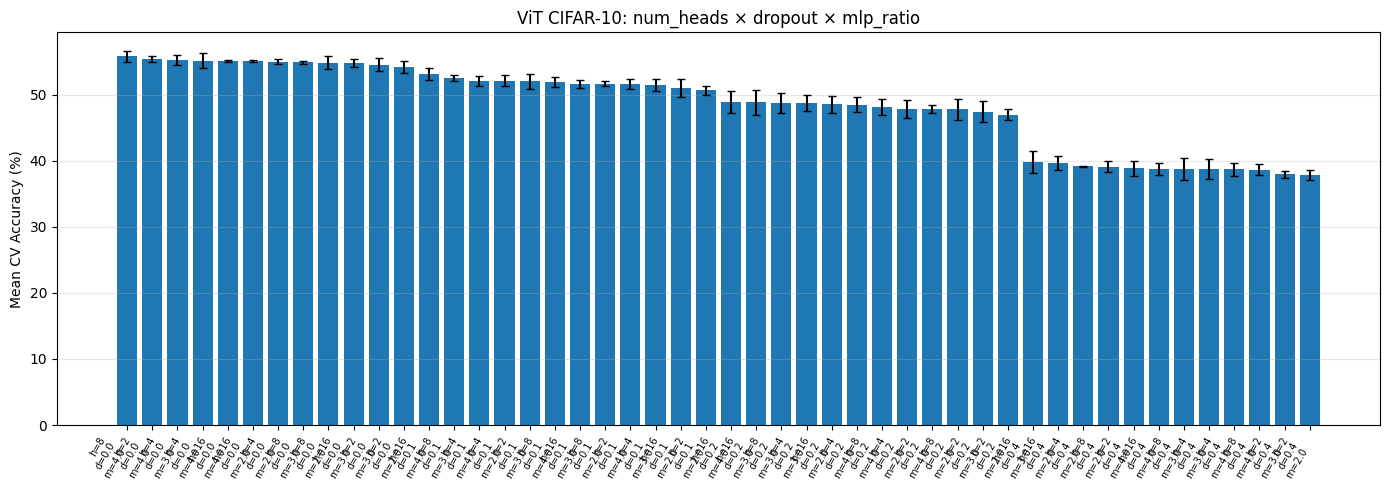

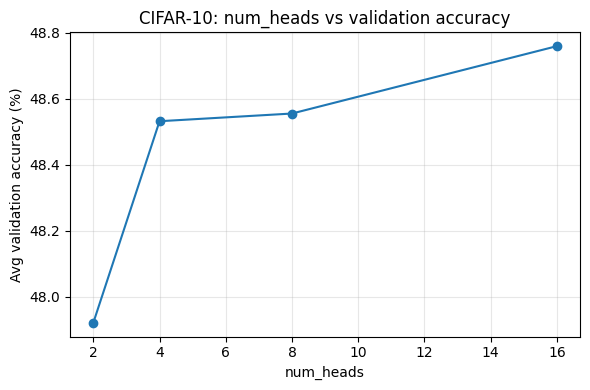

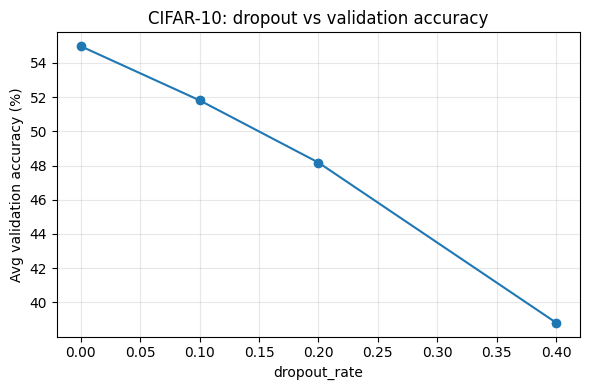

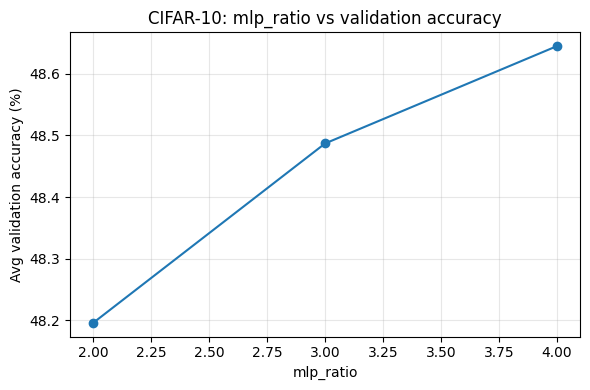


Best configuration:
num_heads               8
dropout_rate          0.0
mlp_ratio             4.0
mean_cv_acc     55.770046
std_cv_acc       0.815213
Name: 0, dtype: object


In [ ]:
# CIFAR-10 Stratified K-Fold validation for Vision_Transformers
# Hyperparameters: num_heads, dropout, mlp_ratio

import sys
import inspect
import importlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedKFold

# --- repo + model ---
repo_root = Path("/content/4803_project_advanced_neural_networks")
model_dir = repo_root / "model"
if str(model_dir) not in sys.path:
    sys.path.insert(0, str(model_dir))

import vision_transformers
importlib.reload(vision_transformers)
Vision_Transformers = vision_transformers.Vision_Transformers

print("Imported vision_transformers from:", vision_transformers.__file__)
print("Vision_Transformers signature:", inspect.signature(Vision_Transformers.__init__))

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# CIFAR-10 preprocessing upgrades:
# - train augmentation: random crop + horizontal flip
# - val uses only tensor+normalize
# (normalization matches previous CIFAR notebooks)

cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(cifar_mean, cifar_std),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(cifar_mean, cifar_std),
    ]
)

# Build base CIFAR dataset without transform; apply per fold.
base_train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=None)

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, y = self.base_dataset[int(self.indices[i])]
        if self.transform is not None:
            x = self.transform(x)
        return x, y

# Faster Colab runs: set e.g. 10000; None = full 50k train
subset_size = 10000
if subset_size is not None and subset_size < len(base_train_data):
    subset_indices = np.random.choice(len(base_train_data), subset_size, replace=False)
    cv_indices = np.asarray(subset_indices, dtype=np.int64)
    cv_targets = np.array(base_train_data.targets)[cv_indices]
else:
    cv_indices = np.arange(len(base_train_data), dtype=np.int64)
    cv_targets = np.array(base_train_data.targets)

cv_dataset = base_train_data

# Fixed ViT geometry for 32x32 CIFAR (patch_size must divide img_size)
img_size = 32
patch_size = 4
in_channels = 3
k_classes = 10
embedded_dim = 128  # divisible by num_heads in grid below
depth = 4

#hyperparameters to test.

num_heads_list = [2, 4, 8, 16]
dropout_rates = [0.0, 0.1, 0.2, 0.4]
mlp_ratios = [2.0,3.0, 4.0]

n_splits = 3
epochs = 20  # increase to 20-50+ for stronger ViT results
batch_size = 64

# Training recipe upgrades
label_smoothing = 0.1
base_lr = 3e-4
weight_decay = 0.05
warmup_epochs = max(1, int(0.1 * epochs))

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
results = []


def evaluate_top1(model: nn.Module, loader: DataLoader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / max(total, 1)


for num_heads in num_heads_list:
    if embedded_dim % num_heads != 0:
        raise ValueError(f"embedded_dim={embedded_dim} must be divisible by num_heads={num_heads}")

    for dropout_rate in dropout_rates:
        for mlp_ratio in mlp_ratios:
            fold_scores = []
            cfg = f"heads={num_heads}, drop={dropout_rate}, mlp_ratio={mlp_ratio}"
            print(f"\nConfig: {cfg}")

            for fold_id, (train_idx, val_idx) in enumerate(
                skf.split(np.zeros(len(cv_targets)), cv_targets), start=1
            ):
                # Map fold indices into the (possibly) subset index space
                fold_train_indices = cv_indices[train_idx]
                fold_val_indices = cv_indices[val_idx]

                train_subset = TransformSubset(cv_dataset, fold_train_indices, train_transform)
                val_subset = TransformSubset(cv_dataset, fold_val_indices, val_transform)

                train_loader = DataLoader(
                    train_subset,
                    batch_size=batch_size,
                    shuffle=True,
                    num_workers=2,
                    pin_memory=True,
                )
                val_loader = DataLoader(
                    val_subset,
                    batch_size=batch_size,
                    shuffle=False,
                    num_workers=2,
                    pin_memory=True,
                )

                model = Vision_Transformers(
                    img_size=img_size,
                    patch_size=patch_size,
                    in_channels=in_channels,
                    k_classes=k_classes,
                    embedded_dim=embedded_dim,
                    depth=depth,
                    num_heads=num_heads,
                    mlp_ratio=mlp_ratio,
                    dropout=dropout_rate,
                ).to(device)

                optimizer = optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)

                # Warmup + cosine schedule (strong default for ViTs)
                warmup = optim.lr_scheduler.LinearLR(
                    optimizer,
                    start_factor=0.1,
                    end_factor=1.0,
                    total_iters=warmup_epochs,
                )
                cosine = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer,
                    T_max=max(1, epochs - warmup_epochs),
                )
                scheduler = optim.lr_scheduler.SequentialLR(
                    optimizer,
                    schedulers=[warmup, cosine],
                    milestones=[warmup_epochs],
                )

                loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

                for epoch in range(1, epochs + 1):
                    model.train()
                    for images, labels in train_loader:
                        images, labels = images.to(device), labels.to(device)
                        optimizer.zero_grad()
                        loss = loss_fn(model(images), labels)
                        loss.backward()
                        optimizer.step()
                    scheduler.step()

                acc = evaluate_top1(model, val_loader)
                fold_scores.append(acc)
                print(f"  Fold {fold_id}/{n_splits}: val_acc={acc:.2f}%")

            results.append(
                {
                    "num_heads": num_heads,
                    "dropout_rate": dropout_rate,
                    "mlp_ratio": mlp_ratio,
                    "mean_cv_acc": float(np.mean(fold_scores)),
                    "std_cv_acc": float(np.std(fold_scores)),
                    "fold_scores": fold_scores,
                }
            )

results_df = (
    pd.DataFrame(results)
    .sort_values("mean_cv_acc", ascending=False)
    .reset_index(drop=True)
)
print("\nTop configurations:")
print(
    results_df[
        ["num_heads", "dropout_rate", "mlp_ratio", "mean_cv_acc", "std_cv_acc"]
    ].head(15)
)

# Plot: all triplets (bar chart)
plt.figure(figsize=(14, 5))
labels = [
    f"h={r.num_heads}\nd={r.dropout_rate}\nm={r.mlp_ratio}"
    for r in results_df.itertuples()
]
plt.bar(
    range(len(results_df)),
    results_df["mean_cv_acc"],
    yerr=results_df["std_cv_acc"],
    capsize=3,
)
plt.xticks(range(len(results_df)), labels, rotation=60, ha="right", fontsize=7)
plt.ylabel("Mean CV Accuracy (%)")
plt.title("ViT CIFAR-10: num_heads × dropout × mlp_ratio")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Marginal effect: num_heads
h_eff = results_df.groupby("num_heads", as_index=False)["mean_cv_acc"].mean().sort_values("num_heads")
plt.figure(figsize=(6, 4))
plt.plot(h_eff["num_heads"], h_eff["mean_cv_acc"], marker="o")
plt.xlabel("num_heads")
plt.ylabel("Avg validation accuracy (%)")
plt.title("CIFAR-10: num_heads vs validation accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Marginal: dropout
d_eff = results_df.groupby("dropout_rate", as_index=False)["mean_cv_acc"].mean().sort_values("dropout_rate")
plt.figure(figsize=(6, 4))
plt.plot(d_eff["dropout_rate"], d_eff["mean_cv_acc"], marker="o")
plt.xlabel("dropout_rate")
plt.ylabel("Avg validation accuracy (%)")
plt.title("CIFAR-10: dropout vs validation accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Marginal: mlp_ratio
m_eff = results_df.groupby("mlp_ratio", as_index=False)["mean_cv_acc"].mean().sort_values("mlp_ratio")
plt.figure(figsize=(6, 4))
plt.plot(m_eff["mlp_ratio"], m_eff["mean_cv_acc"], marker="o")
plt.xlabel("mlp_ratio")
plt.ylabel("Avg validation accuracy (%)")
plt.title("CIFAR-10: mlp_ratio vs validation accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print("\nBest configuration:")
print(
    best[
        [
            "num_heads",
            "dropout_rate",
            "mlp_ratio",
            "mean_cv_acc",
            "std_cv_acc",
        ]
    ]
)


## Tiny ImageNet-200: Final ViT Validation (Stratified K-Fold)

Final validation pipeline for `Vision_Transformers` on Tiny ImageNet-200 using the same hyperparameters as CIFAR-10:

- `num_heads`
- `dropout_rate`
- `mlp_ratio`

This section uses a Tiny ImageNet loader + Stratified K-Fold on the train split, with ImageNet normalization and train-time augmentation.


In [6]:
# Tiny ImageNet-200 final validation for Vision_Transformers
# Same hyperparameter family as CIFAR-10: num_heads, dropout_rate, mlp_ratio

import os
import sys
import zipfile
import urllib.request
import inspect
import importlib
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold

# Repo + model reload
repo_root = Path("/content/4803_project_advanced_neural_networks")
model_dir = repo_root / "model"
if str(model_dir) not in sys.path:
    sys.path.insert(0, str(model_dir))

import importlib.util

vision_path = model_dir / "vision_transformers.py"
if not vision_path.exists():
    raise FileNotFoundError(
        f"Could not find {vision_path}. Run the clone/pull cell and verify repo path."
    )

spec = importlib.util.spec_from_file_location("vision_transformers", vision_path)
vision_transformers = importlib.util.module_from_spec(spec)
spec.loader.exec_module(vision_transformers)
Vision_Transformers = vision_transformers.Vision_Transformers

print("Imported vision_transformers from:", vision_path)
print("Vision_Transformers signature:", inspect.signature(Vision_Transformers.__init__))

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Tiny ImageNet data setup
data_root = repo_root / "model" / "data"
data_root.mkdir(parents=True, exist_ok=True)

tiny_zip_url = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
tiny_zip_path = data_root / "tiny-imagenet-200.zip"
tiny_root = data_root / "tiny-imagenet-200"

if not tiny_root.exists():
    if not tiny_zip_path.exists():
        print("Downloading Tiny ImageNet-200...")
        urllib.request.urlretrieve(tiny_zip_url, tiny_zip_path)
    print("Extracting Tiny ImageNet-200...")
    with zipfile.ZipFile(tiny_zip_path, "r") as zf:
        zf.extractall(data_root)

print(f"Tiny ImageNet root: {tiny_root}")

# Tiny ImageNet datasets
class TinyImageNetTrainDataset(Dataset):
    def __init__(self, root: Path):
        self.root = Path(root)

        wnids_path = self.root / "wnids.txt"
        self.classes = [line.strip() for line in wnids_path.read_text().splitlines() if line.strip()]
        self.class_to_idx = {wnid: idx for idx, wnid in enumerate(self.classes)}

        self.samples = []
        train_dir = self.root / "train"
        for wnid in self.classes:
            img_dir = train_dir / wnid / "images"
            if not img_dir.exists():
                continue
            y = self.class_to_idx[wnid]
            for img_path in img_dir.glob("*.JPEG"):
                self.samples.append((img_path, y))

        self.targets = np.array([y for _, y in self.samples], dtype=np.int64)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        return image, label


class TransformSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, y = self.base_dataset[int(self.indices[i])]
        if self.transform is not None:
            x = self.transform(x)
        return x, y

# Transforms (similar style to previous models)
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose(
    [
        transforms.RandomCrop(64, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

base_train_data = TinyImageNetTrainDataset(tiny_root)
num_classes = len(base_train_data.classes)
print(f"Train samples: {len(base_train_data)} | Classes: {num_classes}")

# Optional subset for faster CV
# Set to None for full Tiny ImageNet train split (~100k images)
subset_size = 20000
if subset_size is not None and subset_size < len(base_train_data):
    subset_indices = np.random.choice(len(base_train_data), subset_size, replace=False)
    cv_indices = np.asarray(subset_indices, dtype=np.int64)
    cv_targets = base_train_data.targets[cv_indices]
else:
    cv_indices = np.arange(len(base_train_data), dtype=np.int64)
    cv_targets = base_train_data.targets

# ViT settings + hyperparameters
img_size = 64
patch_size = 8
in_channels = 3
k_classes = num_classes
embedded_dim = 128
depth = 6

# Same family as CIFAR pipeline
num_heads_list = [2, 4, 8, 16]
dropout_rates = [0.0, 0.1, 0.2, 0.4]
mlp_ratios = [2.0, 3.0, 4.0]

n_splits = 3
epochs = 20  # increase to 20-50+ for final long runs
batch_size = 64

# Training recipe
label_smoothing = 0.1
base_lr = 3e-4
weight_decay = 0.05
warmup_epochs = max(1, int(0.1 * epochs))

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Save after each finished (num_heads, dropout, mlp_ratio) combo so Colab crashes lose less work
checkpoint_json = data_root / "tiny_vit_cv_checkpoint.json"


def ckpt_save():
    with open(checkpoint_json, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)
    print(f"Checkpoint saved: {checkpoint_json} ({len(results)} completed configs)")


results = []
if checkpoint_json.exists():
    try:
        with open(checkpoint_json, "r", encoding="utf-8") as f:
            results = json.load(f)
        print(f"Loaded checkpoint ({len(results)} configs). Completed configs will be skipped.")
    except json.JSONDecodeError:
        results = []

_completed = {
    (int(r["num_heads"]), float(r["dropout_rate"]), float(r["mlp_ratio"])) for r in results
}


def evaluate_top1(model: nn.Module, loader: DataLoader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / max(total, 1)


for num_heads in num_heads_list:
    if embedded_dim % num_heads != 0:
        raise ValueError(f"embedded_dim={embedded_dim} must be divisible by num_heads={num_heads}")

    for dropout_rate in dropout_rates:
        for mlp_ratio in mlp_ratios:
            key_cfg = (int(num_heads), float(dropout_rate), float(mlp_ratio))
            cfg = f"heads={num_heads}, drop={dropout_rate}, mlp_ratio={mlp_ratio}"

            if key_cfg in _completed:
                print(f"\n(skip) Already checkpointed: {cfg}")
                continue

            fold_scores = []
            print(f"\nConfig: {cfg}")

            for fold_id, (train_idx, val_idx) in enumerate(
                skf.split(np.zeros(len(cv_targets)), cv_targets), start=1
            ):
                fold_train_indices = cv_indices[train_idx]
                fold_val_indices = cv_indices[val_idx]

                train_subset = TransformSubset(base_train_data, fold_train_indices, train_transform)
                val_subset = TransformSubset(base_train_data, fold_val_indices, val_transform)

                train_loader = DataLoader(
                    train_subset,
                    batch_size=batch_size,
                    shuffle=True,
                    num_workers=2,
                    pin_memory=True,
                )
                val_loader = DataLoader(
                    val_subset,
                    batch_size=batch_size,
                    shuffle=False,
                    num_workers=2,
                    pin_memory=True,
                )

                model = Vision_Transformers(
                    img_size=img_size,
                    patch_size=patch_size,
                    in_channels=in_channels,
                    k_classes=k_classes,
                    embedded_dim=embedded_dim,
                    depth=depth,
                    num_heads=num_heads,
                    mlp_ratio=mlp_ratio,
                    dropout=dropout_rate,
                ).to(device)

                optimizer = optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)

                warmup = optim.lr_scheduler.LinearLR(
                    optimizer,
                    start_factor=0.1,
                    end_factor=1.0,
                    total_iters=warmup_epochs,
                )
                cosine = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer,
                    T_max=max(1, epochs - warmup_epochs),
                )
                scheduler = optim.lr_scheduler.SequentialLR(
                    optimizer,
                    schedulers=[warmup, cosine],
                    milestones=[warmup_epochs],
                )

                loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

                for _ in range(epochs):
                    model.train()
                    for images, labels in train_loader:
                        images, labels = images.to(device), labels.to(device)
                        optimizer.zero_grad()
                        loss = loss_fn(model(images), labels)
                        loss.backward()
                        optimizer.step()
                    scheduler.step()

                acc = evaluate_top1(model, val_loader)
                fold_scores.append(acc)
                print(f"  Fold {fold_id}/{n_splits}: val_acc={acc:.2f}%")

            results.append(
                {
                    "num_heads": num_heads,
                    "dropout_rate": dropout_rate,
                    "mlp_ratio": mlp_ratio,
                    "mean_cv_acc": float(np.mean(fold_scores)),
                    "std_cv_acc": float(np.std(fold_scores)),
                    "fold_scores": fold_scores,
                }
            )
            _completed.add(key_cfg)
            ckpt_save()

results_df = pd.DataFrame(results).sort_values("mean_cv_acc", ascending=False).reset_index(drop=True)
print("\nTop configurations:")
print(results_df[["num_heads", "dropout_rate", "mlp_ratio", "mean_cv_acc", "std_cv_acc"]].head(15))

# Plot all triplets
plt.figure(figsize=(14, 5))
labels = [f"h={r.num_heads}\nd={r.dropout_rate}\nm={r.mlp_ratio}" for r in results_df.itertuples()]
plt.bar(range(len(results_df)), results_df["mean_cv_acc"], yerr=results_df["std_cv_acc"], capsize=3)
plt.xticks(range(len(results_df)), labels, rotation=60, ha="right", fontsize=7)
plt.ylabel("Mean CV Accuracy (%)")
plt.title("ViT Tiny ImageNet-200: num_heads × dropout × mlp_ratio")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Marginal: num_heads
h_eff = results_df.groupby("num_heads", as_index=False)["mean_cv_acc"].mean().sort_values("num_heads")
plt.figure(figsize=(6, 4))
plt.plot(h_eff["num_heads"], h_eff["mean_cv_acc"], marker="o")
plt.xlabel("num_heads")
plt.ylabel("Avg validation accuracy (%)")
plt.title("Tiny ImageNet-200: num_heads vs validation accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Marginal: dropout
d_eff = results_df.groupby("dropout_rate", as_index=False)["mean_cv_acc"].mean().sort_values("dropout_rate")
plt.figure(figsize=(6, 4))
plt.plot(d_eff["dropout_rate"], d_eff["mean_cv_acc"], marker="o")
plt.xlabel("dropout_rate")
plt.ylabel("Avg validation accuracy (%)")
plt.title("Tiny ImageNet-200: dropout vs validation accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Marginal: mlp_ratio
m_eff = results_df.groupby("mlp_ratio", as_index=False)["mean_cv_acc"].mean().sort_values("mlp_ratio")
plt.figure(figsize=(6, 4))
plt.plot(m_eff["mlp_ratio"], m_eff["mean_cv_acc"], marker="o")
plt.xlabel("mlp_ratio")
plt.ylabel("Avg validation accuracy (%)")
plt.title("Tiny ImageNet-200: mlp_ratio vs validation accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print("\nBest configuration:")
print(best[["num_heads", "dropout_rate", "mlp_ratio", "mean_cv_acc", "std_cv_acc"]])


Imported vision_transformers from: /content/4803_project_advanced_neural_networks/model/vision_transformers.py
Vision_Transformers signature: (self, img_size, patch_size, in_channels, k_classes, embedded_dim, depth, num_heads, mlp_ratio, dropout)
Device: cuda
Extracting Tiny ImageNet-200...
Tiny ImageNet root: /content/4803_project_advanced_neural_networks/model/data/tiny-imagenet-200
Train samples: 100000 | Classes: 200

Config: heads=2, drop=0.0, mlp_ratio=2.0
  Fold 1/3: val_acc=14.79%
  Fold 2/3: val_acc=15.18%
  Fold 3/3: val_acc=15.35%

Config: heads=2, drop=0.0, mlp_ratio=3.0
  Fold 1/3: val_acc=15.72%
  Fold 2/3: val_acc=14.97%
  Fold 3/3: val_acc=15.45%

Config: heads=2, drop=0.0, mlp_ratio=4.0
  Fold 1/3: val_acc=15.55%
  Fold 2/3: val_acc=14.94%
  Fold 3/3: val_acc=16.34%

Config: heads=2, drop=0.1, mlp_ratio=2.0
  Fold 1/3: val_acc=13.89%
  Fold 2/3: val_acc=13.38%
  Fold 3/3: val_acc=13.32%

Config: heads=2, drop=0.1, mlp_ratio=3.0
  Fold 1/3: val_acc=12.93%
  Fold 2/3: va

: 

# Interrupted Validation 

Due to the complexity of the dataset and the architecture that the validation pipeline was working  the runtime on Colab GPU server suddenly stopped. However I was able to recover the proposed parameters that are going to be the most optimal when it comes for our vision transfomers architecture .  

Optimal Hyperparameters:


* **Number of Heads**: 8
* **MLP ratio**: 4
* **dropout rate** = 0.0